# 07 — Insurance pricing, end to end

A general regression report tells a pricing committee that the model is "wrong
by 129,697 naira on average". Nobody has ever been able to act on that
sentence. What the committee asks instead:

1. **Did the book collect what it needed to?** — actual against expected.
2. **Is the shortfall everywhere, or in one band?** — A/E by decile.
3. **Does the tariff order risk at all?** — the Lorenz Gini.
4. **Does premium still rise with prior claims?** — monotonicity, because that
   is what was filed.
5. **Who gets a 30% increase?** — dislocation against the incumbent.

An RMSE answers none of them, and it is symmetric about zero, so a model that
over-charges half the book and under-charges the other half scores exactly
like one that is right everywhere.

This notebook gates a motor pricing model that is genuinely *good* — it
discriminates markedly better than the tariff it replaces — and is still not
shippable, for reasons no error metric in this library would have surfaced.
Everything here is regression-only and needs no scikit-learn beyond fitting
the model itself.

Assumes [01](01_binary_classification_sklearn.ipynb) for the core machinery
and [03](03_regression_sklearn.ipynb) for the regression fairness notions.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

import bdp_model_gate

print("bdp-model-gate", bdp_model_gate.__version__)

bdp-model-gate 0.5.3


## A book of motor policies

Two things about this data matter more than the rating factors.

**The target is a rate, not a total.** `loss_cost` is claims cost per
exposure-year, which is what a pricing model predicts. That is the case
`context.exposure` exists for.

**The exposures are mixed.** A fifth of this book is written monthly and two
fifths annually, so a policy contributing one month of evidence sits beside
one contributing twelve. Roughly four fifths of policies have no claim at all,
which is ordinary for motor and is why the target is so skewed.

In [2]:
rng = np.random.default_rng(20260902)
n = 2500

exposure = np.round(rng.choice([1 / 12, 0.25, 0.5, 1.0], n, p=[0.20, 0.20, 0.20, 0.40]), 4)
driver_age = rng.integers(19, 71, n).astype(float)
vehicle_value = np.round(rng.lognormal(15.3, 0.45, n), -3)
prior_claims = rng.choice([0, 1, 2, 3, 4], n, p=[0.62, 0.22, 0.10, 0.04, 0.02]).astype(float)
region = rng.choice(["Lagos", "Abuja", "Kano", "Port Harcourt"], n, p=[0.45, 0.2, 0.2, 0.15])
annual_km = np.round(rng.gamma(6, 2500, n), -2)

territory = {"Lagos": 1.25, "Abuja": 0.95, "Kano": 0.80, "Port Harcourt": 1.10}
region_risk = pd.Series(region).map(territory).to_numpy()

X = pd.DataFrame(
    {
        "driver_age": driver_age,
        "vehicle_value_ngn": vehicle_value,
        "prior_claims": prior_claims,
        "annual_km": annual_km,
        "region_risk": region_risk,
    }
)

# The technical premium the actuarial team signed off: pure risk cost per
# exposure-year, before any loading. It is what `expected_loss` should carry.
age_factor = 1.6 - 0.9 * np.clip((driver_age - 19) / 40, 0, 1)
technical_premium = (
    28_000
    * age_factor
    * (vehicle_value / 4_000_000) ** 0.6
    * (1 + 0.45 * prior_claims)
    * region_risk
    * (annual_km / 15_000) ** 0.35
)

# Realised experience: a Poisson claim count at that rate, gamma severities.
counts = rng.poisson(exposure * technical_premium / 90_000)
loss_cost = counts * rng.gamma(2.2, 90_000 / 2.2, n) / exposure

pd.DataFrame(
    {
        "exposure_years": exposure,
        "prior_claims": prior_claims,
        "technical_premium": technical_premium.round(0),
        "loss_cost": loss_cost.round(0),
    }
).describe().round(2)

,exposure_years,prior_claims,technical_premium,loss_cost
count,2500.00,2500.00,2500.00,2500.00
mean,0.56,0.64,44611.17,43746.14
std,0.38,0.98,26661.03,141741.79
min,0.08,0.00,8006.00,0.00
25%,0.25,0.00,26131.50,0.00
50%,0.50,0.00,37839.50,0.00
75%,1.00,1.00,55728.00,0.00
max,1.00,4.00,242620.00,2149858.00


## The model, and the two business rules bolted to it

The estimator is a gradient booster fitted on the loss cost, **weighted by
exposure** — `sample_weight=exposure`, so an annual policy counts for twelve
times a monthly one during fitting as well as during scoring.

Then two rules that live outside the estimator, both of which exist in real
tariffs:

- **A rate cap.** Premiums above a filed ceiling are held down by 20%.
- **A capped claims loading with a retention discount.** The claims loading
  stops at two claims, and policies with three or more get 15% off to keep
  them on the book.

Both are gated, because **`predict_fn` is the deployed scoring function, not
the estimator.** Gating the booster alone would test a model nobody prices
with.

In [3]:
gbm = GradientBoostingRegressor(n_estimators=250, max_depth=3, learning_rate=0.06, random_state=0)
gbm.fit(X, loss_cost, sample_weight=exposure)

RATE_CAP = float(np.quantile(np.clip(gbm.predict(X), 1_000, None), 0.90))


def price_v4(frame):
    """The deployed tariff: the booster plus the two filed business rules."""
    scored = frame.copy()
    scored["prior_claims"] = scored["prior_claims"].clip(upper=2.0)  # loading capped at 2
    base = np.clip(gbm.predict(scored), 1_000.0, None)
    premium = base.copy()
    premium[base >= RATE_CAP] *= 0.80                               # rate cap
    premium[frame["prior_claims"].to_numpy() >= 3] *= 0.85          # retention discount
    return premium


# The incumbent: last year's tariff, rated on age, vehicle value and territory
# only. It is the thing v4 has to be compared against, not beaten in the
# abstract.
INCUMBENT_FACTORS = ["driver_age", "vehicle_value_ngn", "region_risk"]
v3 = GradientBoostingRegressor(n_estimators=120, max_depth=2, learning_rate=0.08, random_state=1)
v3.fit(X[INCUMBENT_FACTORS], loss_cost, sample_weight=exposure)


def price_v3(frame):
    return np.clip(v3.predict(frame[INCUMBENT_FACTORS]), 1_000.0, None)


premium = price_v4(X)
incumbent = price_v3(X)
print(f"rate cap applies above {RATE_CAP:,.0f}")
print(f"mean premium  v4 {premium.mean():,.0f}   v3 {incumbent.mean():,.0f}")

rate cap applies above 81,308
mean premium  v4 42,838   v3 47,129


## Exposure is a correctness question, not a refinement

Before any check runs, look at what ignoring exposure does to two figures.
`context.exposure` weights the regression metrics and the whole actuarial
suite; without it every row counts once, which is the right default for a
per-policy total and the wrong one for a rate.

In [4]:
from bdp_model_gate.actuarial import actual_over_expected
from bdp_model_gate.metrics import resolve_metric


def rmse(weights=None):
    return resolve_metric("rmse", "regression", exposure=weights).fn(loss_cost, premium)


pd.DataFrame(
    {
        "unweighted": [rmse(), actual_over_expected(loss_cost, premium)],
        "exposure-weighted": [rmse(exposure), actual_over_expected(loss_cost, premium, exposure)],
    },
    index=["RMSE", "actual / expected"],
).round(4)

,unweighted,exposure-weighted
RMSE,129697.1114,95187.9376
actual / expected,1.0212,1.0920


Both move, and they move for the same reason in opposite directions.

The unweighted RMSE is inflated by short policies: a one-month policy with a
claim has a *loss cost* of twelve times that claim, and counting it as one
observation exaggerates the error. The unweighted A/E is closer to break-even
by coincidence — the short policies happen to pull it the other way — and a
governance report that quoted it would say this book is 2% out when it is 9%
out.

Neither number is a rounding difference from the other. Pick the wrong one and
you make a different decision.

## Running the gate

Three things are configured, and the rest are defaults:

- `metric="lorenz_gini"` — the pricing convention for discrimination, gated
  with `min_score`. It is exposure-weighted, and it works on a core install.
- `monotonic_features` — the constraint that was *filed*. Nothing is checked
  until it is declared, because a library cannot guess which factors carry one.
- `expected_loss=technical_premium` — so `loss_ratio_parity` can separate a
  territory loading that is justified by cost from one that is not.

Both `predict_fn` and `model` are supplied, and they are not redundant.
**`predict_fn` always wins for prediction**, so every check that scores the
model scores the tariff. `model` is read only by `shap_subgroup_gap`, which
uses it to pick `TreeExplainer` — exact and fast for a booster, where the
black-box explainer would re-score the book thousands of times. The SHAP
attribution is therefore of the estimator, not of the business rules on top of
it.

In [5]:
from bdp_model_gate import (
    ActuarialConfig,
    GateConfig,
    ModelGate,
    PerformanceConfig,
    StructuredGateContext,
)
from bdp_model_gate.structured import default_structured_checks

config = GateConfig(
    performance=PerformanceConfig(metric="lorenz_gini", min_score=0.25),
    actuarial=ActuarialConfig(monotonic_features={"prior_claims": "increasing"}),
)

context = StructuredGateContext(
    predict_fn=price_v4,          # the deployed tariff, rules included
    model=gbm,                    # the estimator underneath it — see the note below
    X=X,
    y_true=loss_cost,
    y_pred=premium,
    exposure=exposure,            # the target is a rate
    baseline_pred=incumbent,      # what it replaces
    expected_loss=technical_premium,
    protected_df=pd.DataFrame({"region": region}),
    model_card={
        "use_case": "pricing",
        "legal_basis": "Contractual necessity (NDPA 2023, s.25(1)(b))",
        "data_minimization_justification": "Filed rating factors only.",
        "training_data_source": "Motor book 2023-2025",
        "validation_strategy": "out_of_time",
        "dpia_completed": True,
        "influences_decision_about_person": True,
        "explainability_method": "Partial dependence, filed with the tariff",
    },
    task="regression",
)

report = ModelGate(checks=default_structured_checks(config)).run(context)
print(report.summary())

Gate status: BLOCKED (1125ms, regression)
  lorenz_gini: 0.5637
  validation: 0 flag(s)
  performance: 2 flag(s)
  compliance: 2 flag(s)
  security: 1 flag(s)
  fairness: 6 flag(s)


In [6]:
PRICING = ["performance_thresholds", "actual_vs_expected", "risk_discrimination",
           "monotonicity", "prediction_dislocation"]

for result in report.results:
    if result.check_name in PRICING:
        print(f"[{result.flag}] {result.check_name}\n    {result.detail}\n")

[OK] performance_thresholds
    lorenz_gini=0.5637 (min 0.25) [exposure-weighted]

[AE_LEVEL_RISK] actual_vs_expected
    book A/E = 1.092 (9.2% from break-even, under-priced; tolerance 5.0%) [exposure-weighted]

[AE_BAND_RISK] actual_vs_expected
    worst band is 10 of 10 (72,076–593,915): A/E = 1.824 over 255 rows — under-priced by 82.4% (tolerance 10.0%) [exposure-weighted]

[OK] risk_discrimination
    Gini = 0.564, 67% of the 0.835 this book allows (floor 0.000) [exposure-weighted]

[MONOTONICITY_RISK] monotonicity
    prior_claims was declared increasing in premium, and is not: between 2 and 4 the mean prediction moves 70,136.39 → 59,615.93, against the declared direction by 30.1% of the curve's range. 1 of 3 steps break it

[DISLOCATION_RISK] prediction_dislocation
    16.3% of exposure rises by 25% or more (tolerance 10.0%); 37.4% falls by as much. 95th percentile move +73.0%, largest rise +2467.4%. Most affected: region=Kano at 20.8% [exposure-weighted]



Read those five together and they are a memo, not a scorecard.

The tariff **discriminates well** — better than what it replaces, as section 2
shows. It is also **under-priced by nine percent overall and by eighty-two
percent in its top decile**, it **violates a filed rating constraint**, and it
moves a sixth of the book by more than a quarter.

None of that says "do not ship". It says which four conversations to have, and
two of them are not statistical conversations at all.

One flag is not shown above: `adversarial_robustness` fires, because a mean
relative prediction shift is a demanding measure on a target this skewed. On a
pricing model it is worth reading as context rather than as a defect —
`adversarial_max_relative_shift` is the field to set against your own book.

## 1. Actual against expected — the level, then the shape

Two findings, because they have different causes and different fixes. An
overall A/E of 1.00 is routinely produced by a model subsidising its worst
risks out of its best: the rate level looks perfect and every individual price
is wrong.

Bands are cut at equal **exposure**, not equal row counts. On a book with a
mixed exposure profile the two differ substantially — equal-count deciles put
most of the year's risk in whichever decile happens to hold the annual
policies.

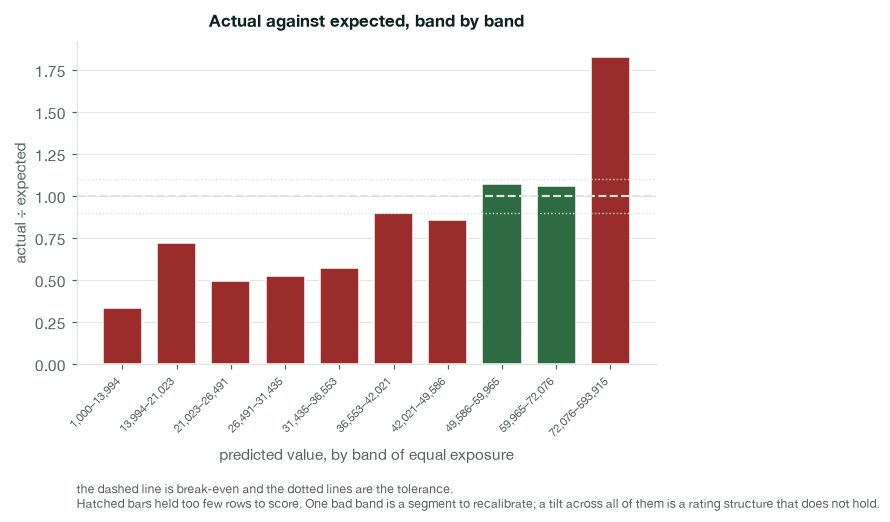

,band,label,n_rows,exposure,ae,scored
0,1,"1,000–13,994",238,140.9150,0.3321,True
1,2,"13,994–21,023",248,140.4153,0.7185,True
2,3,"21,023–26,491",252,141.9983,0.4926,True
3,4,"26,491–31,435",242,140.7485,0.5213,True
4,5,"31,435–36,553",243,141.1653,0.5722,True
5,6,"36,553–42,021",256,141.3316,0.8969,True
6,7,"42,021–49,586",257,141.0814,0.8559,True
7,8,"49,586–59,965",257,140.4150,1.0710,True
8,9,"59,965–72,076",252,140.8317,1.0560,True
9,10,"72,076–593,915",255,141.3318,1.8237,True


In [7]:
import matplotlib.pyplot as plt

from bdp_model_gate.plots import apply_style
from bdp_model_gate.structured.actuarial_checks import ActualVsExpectedCheck

apply_style()

ae_check = ActualVsExpectedCheck(config.actuarial)
ae_results = ae_check.run(context)
ae_check.plot(context, ae_results)
plt.show()

bands = next(r for r in ae_results if r.metadata.get("measure") == "bands")
pd.DataFrame(bands.metadata["bands"])[["band", "label", "n_rows", "exposure", "ae", "scored"]]

The A/E column is not scattered around break-even — it **climbs almost
monotonically** from about a third at the bottom of the book to 1.8 at the
top. That is the signature of a tariff that does not spread enough: the
cheapest deciles are charged roughly three times what they cost, and the
dearest is charged barely more than half.

This is what the overall figure cannot express, and it inverts the remedy.
"Under-priced by nine percent" invites a nine percent rate increase across the
book — which would over-charge the seven deciles that are *already* over-priced
in order to fix the one that is not. The finding is a **rating structure that
needs to spread further**, not a rate level to move.

The rate cap is part of it, and how much is worth measuring rather than
asserting.

In [8]:
from bdp_model_gate.actuarial import assign_bands, band_edges

uncapped = np.clip(gbm.predict(X.assign(prior_claims=X["prior_claims"].clip(upper=2.0))), 1_000, None)
top = assign_bands(premium, band_edges(premium, 10, exposure)) == 9

print(f"top band, as priced      : A/E {actual_over_expected(loss_cost[top], premium[top], exposure[top]):.3f}")
print(f"top band, cap removed    : A/E {actual_over_expected(loss_cost[top], uncapped[top], exposure[top]):.3f}")
print(f"share of the top band capped: {(uncapped[top] >= RATE_CAP).mean():.1%}")

top band, as priced      : A/E 1.824
top band, cap removed    : A/E 1.490
share of the top band capped: 67.5%


So the cap accounts for part of the top decile's shortfall and not all of it:
lift the cap and that band is still well short. Two separate pieces of work,
and the banded view is what separates them.

## 2. The Gini — does the tariff order risk?

Calibration and discrimination are independent, and a pricing review needs
both. A tariff that charges every policy the book average has a perfect A/E
and is useless: it collects the right total and distributes it at random. On a
book where four fifths of policies have no claim, the mean is not even a bad
guess, so every error metric scores it respectably.

The ceiling matters as much as the value. No rating structure can predict
which individual policy crashes, so the attainable maximum is well below 1.0
and varies by class of business.

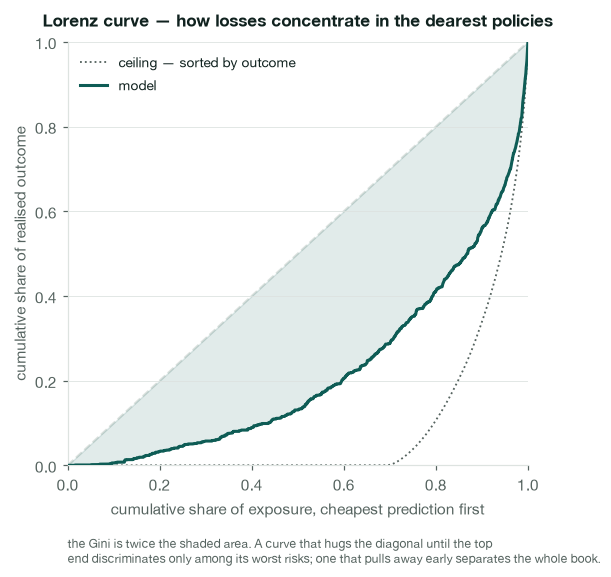

,gini,share of ceiling
v3 (incumbent),0.363,0.434
v4 (proposed),0.564,0.675
ceiling — sorted by outcome,0.835,1.000


In [9]:
from bdp_model_gate.actuarial import lorenz_gini
from bdp_model_gate.structured.actuarial_checks import RiskDiscriminationCheck

gini_check = RiskDiscriminationCheck(config.actuarial)
gini_results = gini_check.run(context)
gini_check.plot(context, gini_results)
plt.show()

ceiling = lorenz_gini(loss_cost, loss_cost, exposure)
pd.DataFrame(
    {
        "gini": [
            lorenz_gini(loss_cost, incumbent, exposure),
            lorenz_gini(loss_cost, premium, exposure),
            ceiling,
        ],
        "share of ceiling": [
            lorenz_gini(loss_cost, incumbent, exposure) / ceiling,
            lorenz_gini(loss_cost, premium, exposure) / ceiling,
            1.0,
        ],
    },
    index=["v3 (incumbent)", "v4 (proposed)", "ceiling — sorted by outcome"],
).round(3)

That table is the business case for the new tariff, and it is one line long:
v4 captures two thirds of the discrimination available in this book where v3
captured under a half.

It is also the number to watch if a rating factor ever gets its sign flipped
in a refactor. A **negative** Gini means the policies priced highest carry the
lower loss per unit of exposure — the ordering is inverted, not merely weak —
and no error metric shows it, because reversing the ordering leaves the
average error almost unchanged.

## 3. Monotonicity — the rule that was filed

The tariff document says premium rises with prior claims. The capped loading
and the retention discount together mean it does not, and **nothing else in
this report notices**: the model scores well, the book prices sensibly on
average, and one segment of policyholders is charged less for being worse
risks.

The check sweeps the factor across the quantiles of its own distribution while
every other column keeps its real joint distribution, so the curve is the
model's actual marginal effect rather than an extrapolation.

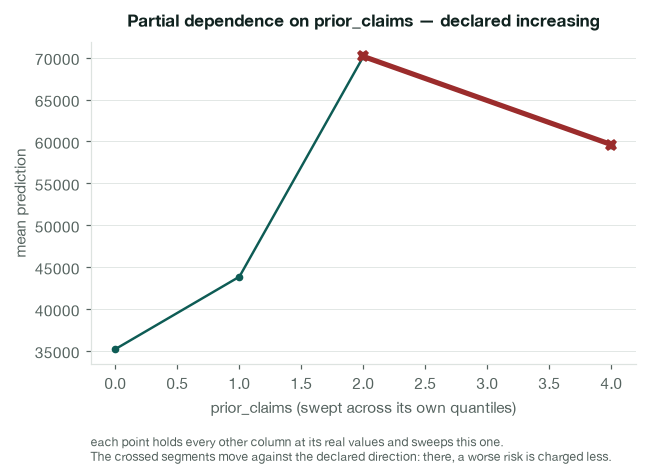

,prior_claims,mean premium
0,0.0,35221.0
1,1.0,43858.0
2,2.0,70136.0
3,4.0,59616.0


In [10]:
from bdp_model_gate.structured.actuarial_checks import MonotonicityCheck

mono_check = MonotonicityCheck(config.actuarial)
mono_results = mono_check.run(context)
mono_check.plot(context, mono_results)
plt.show()

finding = mono_results[0]
pd.DataFrame(
    {
        "prior_claims": finding.metadata["grid"],
        "mean premium": np.round(finding.metadata["partial_dependence"], 0),
    }
)

Premium climbs from zero claims to two, then falls. A policyholder with four
claims is charged less than one with two.

Two things worth knowing about this check before relying on it:

- It only tests what you declare. `monotonic_features` is empty by default,
  because the constraint is a claim about *your* product and its regulator.
- A declared factor it **cannot** evaluate — a misspelled column, a
  categorical one, one that is constant on the validation set — reports
  `MONOTONICITY_UNCHECKABLE` and blocks rather than skipping. A typo in a
  rating-factor name would otherwise produce a green gate on an unverified
  regulatory constraint.

## 4. Dislocation — who moves

The question a pricing committee actually asks about a replacement is not "is
it more accurate?". That was settled two sections ago. It is *"how many
policyholders see a rise above 25%, and are they anyone in particular?"*.

Non-blocking, deliberately. A dislocated book may be entirely correct — that
is often the point of a re-rate — and no threshold can decide whether this
profile is acceptable. The check's job is to put the number and the affected
group in front of a person.

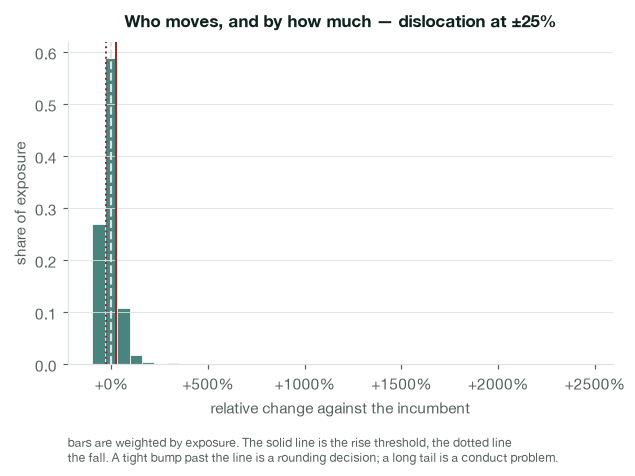

rises >= 25% of exposure : 16.3%
falls >= 25% of exposure : 37.4%
95th percentile move     : +73.0%
largest single rise      : +2467.4%


Lagos            0.1326
Kano             0.2078
Abuja            0.2007
Port Harcourt    0.1476
Name: share of exposure rising >= 25%, dtype: float64

In [11]:
from bdp_model_gate.structured.actuarial_checks import DislocationCheck

dislocation_check = DislocationCheck(config.actuarial)
dislocation_results = dislocation_check.run(context)
dislocation_check.plot(context, dislocation_results)
plt.show()

moves = dislocation_results[0].metadata
print(f"rises >= 25% of exposure : {moves['rise_share']:.1%}")
print(f"falls >= 25% of exposure : {moves['fall_share']:.1%}")
print(f"95th percentile move     : {moves['p95_change']:+.1%}")
print(f"largest single rise      : {moves['largest_rise']:+.1%}")
pd.Series(moves["rise_share_by_group"]["region"], name="share of exposure rising >= 25%")

Read the 95th percentile, not the maximum. The largest rise here comes from a
handful of policies the incumbent priced at its 1,000 floor, where any move is
a large *relative* move; the percentile is the figure that describes the book.

More of this book *falls* by a quarter than rises by one, which is what
happens when a tariff that under-spreads is replaced by one that spreads
further.

The per-region breakdown is the reason this is reported at all, and here it is
the reassuring half of the answer: the rise share runs from 13% to 21% across
the four territories, so the dislocation is broadly spread rather than landing
on one region. That is a question the headline figure cannot answer either
way, and a conduct team has to ask it.

## Territory rating, and why three fairness checks fire

`region` is the protected attribute here and `region_risk` is a filed rating
factor derived from it, so `proxy_correlation` reports η² = 1.000. That is
correct and not a finding: territory rating is **explicit**, not a proxy, and
this is what the check looks like when the attribute is a declared factor.

`group_mean_gap` and `error_parity` fire for the same structural reason. A
pricing model *should* charge more in a higher-loss territory — that is
risk-based pricing, not discrimination — so a raw mean gap flags legitimate
rating differences and is noisy on its own.

`loss_ratio_parity` is the check that separates the two, and the one to read.
It asks whether a group is charged a higher **margin over its own expected
cost**, which is the question a regulator asks.

In [12]:
FAIRNESS = ["proxy_correlation", "group_mean_gap", "loss_ratio_parity"]

for result in report.results:
    if result.check_name in FAIRNESS:
        print(f"[{result.flag}] {result.check_name}\n    {result.detail}\n")

[PROXY_RISK] proxy_correlation
    region_risk correlates with region (eta^2=1.000)

[MEAN_GAP_RISK] group_mean_gap
    region: mean prediction spans 33,324.86 (Kano) to 49,470.95 (Lagos) — 37.4% of the overall mean 43,182.98 [exposure-weighted]

[LOSS_RATIO_RISK] loss_ratio_parity
    region: premium-to-expected-loss ratio spans 0.860 (Abuja) to 1.170 (Port Harcourt) — 29.8% of the overall ratio 1.041; Port Harcourt carries the higher margin over its own expected cost [exposure-weighted]



So the margin is *not* flat across territories, and that is a real finding
rather than an artefact of risk-based pricing: one territory carries a
noticeably higher loading over its own technical premium than another does.
Unlike the mean gap, that difference is not explained by cost, and it needs an
answer before this tariff is filed.

The general rule for a pricing book: read `loss_ratio_parity` first, and treat
`group_mean_gap` and `error_parity` as context for it rather than as findings
in their own right.

## The report a committee signs

One self-contained HTML file — no script, no stylesheet, no font, nothing
fetched from anywhere. Each chart sits beside the number it explains, and
every skipped check says why it was skipped.

In [13]:
report.to_html("pricing_gate_report.html")
print(f"gate status: {report.gate_status}")
print(f"{len(report.flags)} finding(s) across {len(report.results)} results")

gate status: BLOCKED
11 finding(s) across 31 results


## What to take from this

**Exposure is a correctness question.** On a rate target, an unweighted metric
answers a different question. Supply `context.exposure` and the report says
which one you got.

**Level, shape and ordering are three independent ways to be wrong.** A/E
catches the first two, the Gini the third, and one error metric collapses all
three into a number that hides each. This tariff was under-priced in one
decile while discriminating better than its predecessor — a summary no single
scalar can carry.

**Gate the scoring function, not the estimator.** Both defects here live in
business rules bolted on top of a booster that was fine. `predict_fn` is where
the tariff actually is.

**Two of the four findings are not statistical.** A broken monotonicity
constraint and a dislocation profile are conversations with a regulator and a
conduct team. Getting them into the same report as the AUC is the point.

Next: [Reports and plots](06_reports_and_plots.ipynb) for the charts across
every task, or the
[checks reference](https://vanjy-eng.github.io/model-gate/docs/reference/checks/)
for what each threshold means.